In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/home/ubuntu22/4761-project/src")

from spatial_mrf.model_HMRF import AW_HMRF

import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad    



In [2]:
# processed and downloaded adata in MERFISH.ipynb
adata=sc.read_h5ad("/home/ubuntu22/4761-project/data/Zhuang_1080_embedded.h5ad")

In [3]:
#build physical edges based on spatial coordinates and weight them by anatomical boundaries.
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix


k_neighbors = 8
alpha_penalty = 0.2

# Build the spatial graph using native MERFISH coordinates
spatial_coords = adata.obsm['spatial'][:, :2]
knn_model = NearestNeighbors(n_neighbors=k_neighbors+1, algorithm='ball_tree').fit(spatial_coords)
distances, indices = knn_model.kneighbors(spatial_coords)


ccf_label_column = 'ccf_parcellation_index'

print(f"Using anatomy labels from: {ccf_label_column}")
anatomy_labels = adata.obs[ccf_label_column].values

# Validate that anatomy labels are not all NaN
if pd.isna(anatomy_labels).all():
    raise ValueError(f"All values in {ccf_label_column} are NaN. CCF alignment may have failed.")

rows = []
cols = []
weights = []

# Construct the Anatomy-Weighted Adjacency Matrix
for i in range(len(indices)):
    for j_idx in range(1, k_neighbors+1):
        neighbor_i = indices[i, j_idx]
        
        rows.append(i)
        cols.append(neighbor_i)

        # AW Logic: Check if physical neighbors belong to the same official brain region
        # Handle NaN values gracefully
        if pd.isna(anatomy_labels[i]) or pd.isna(anatomy_labels[neighbor_i]):
            weights.append(alpha_penalty)  # Use penalty for unknown regions
        elif anatomy_labels[i] == anatomy_labels[neighbor_i]:
            weights.append(1.0)
        else:
            weights.append(alpha_penalty)

W_aw = csr_matrix((weights, (rows, cols)), shape=(len(spatial_coords), len(spatial_coords)))

print(f"AW-Adjacency Matrix built.")
print(f"Matrix shape: {W_aw.shape}, Non-zero edges: {W_aw.nnz}")


Using anatomy labels from: ccf_parcellation_index
AW-Adjacency Matrix built.
Matrix shape: (37068, 37068), Non-zero edges: 296544


In [4]:
embedding_pca = adata.obsm['X_pca']

In [5]:
from spatial_mrf.model_HMRF import AW_HMRF

results = {}

for beta in [0.01, 1.0, 1.5]:
    model = AW_HMRF(
        n_regions=30,
        beta=beta,
        max_em_iter=10,
        max_icm_iter=5,
    )

    res = model.fit(embedding_pca, W_aw) 
    results[beta] = res # 存储整个对象
    
    print(f"beta={beta} done")

beta=0.01 done
beta=1.0 done
beta=1.5 done


--- Visualizing Convergence for Beta = 0.01 ---


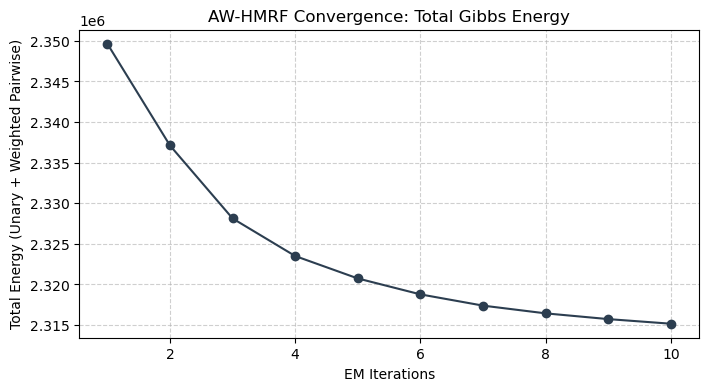

--- Visualizing Convergence for Beta = 1.0 ---


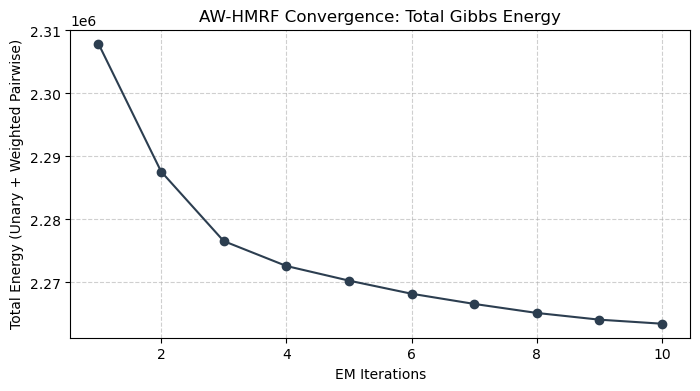

--- Visualizing Convergence for Beta = 1.5 ---


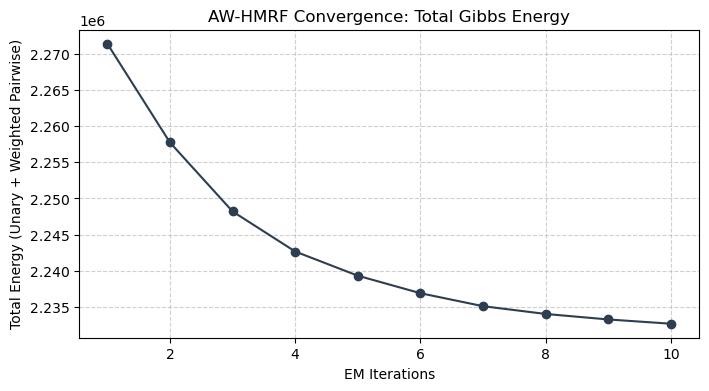

In [ ]:
# energy history evaluation
from spatial_mrf.evaluation import plot_energy_history
for beta, res in results.items():
    print(f"--- Visualizing Convergence for Beta = {beta} ---")
    plot_energy_history(res) 

The Gibbs Energy convergence plots confirm the numerical stability of our AW-HMRF framework. Regardless of the $\beta$ value, the model consistently reaches an energy plateau within 10 iterations, indicating that the ICM solver efficiently navigates the complex landscape formed by the anatomical priors and the transcriptomic embeddings of 37,068 cells.

/tmp/ipykernel_32277/1800014151.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


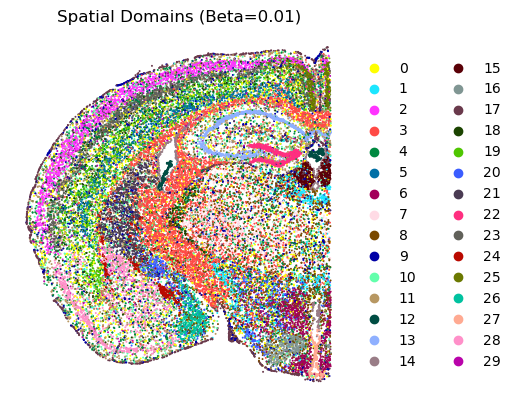

/tmp/ipykernel_32277/1800014151.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


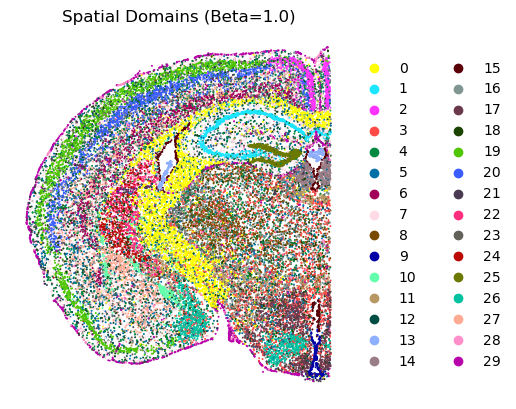

/tmp/ipykernel_32277/1800014151.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


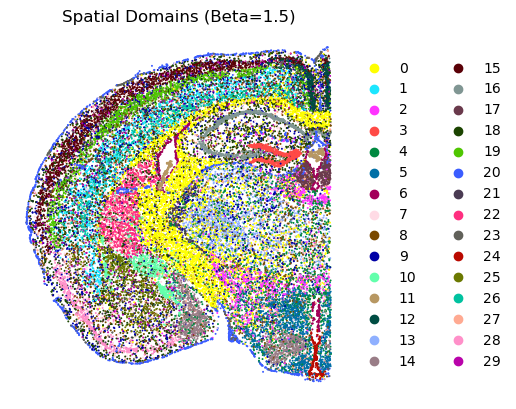

In [ ]:
# visulization of HMRF results on spatial coordinates
import matplotlib.pyplot as plt
import scanpy as sc

# adata with spatial coordinates and HMRF results
for beta, res in results.items():
    col_name = f'AW_HMRF_beta_{beta}'
    adata.obs[col_name] = pd.Categorical(res.states)
    
    sc.pl.spatial(
        adata, 
        color=[col_name], 
        title=f"Spatial Domains (Beta={beta})",
        spot_size=0.034, # 37068 cells
        frameon=False
    )

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

#ref_categories = adata.obs['ccf_parcellation_index'].unique()
#NAN error with ccf_parcellation_index
ref_categories = adata.obs['cluster_alias'].unique()

cmap = plt.get_cmap('tab20')
colors = [plt.cm.colors.to_hex(cmap(i % 20)) for i in range(len(ref_categories))]

color_map = dict(zip(ref_categories, colors))

#adata.uns[f'{"ccf_parcellation_index"}_colors'] = colors   
adata.uns[f'{"cluster_alias"}_colors'] = colors

In [31]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment

def remap_clusters_to_atlas(adata, cluster_col, label_col):
    """
    Hungarian matching for best label matching between cluster labels and atlas labels.
    """

    clusters = adata.obs[cluster_col].astype(str)
    labels = adata.obs[label_col].astype(str)

    # row: label, column: cluster 
    cm_df = pd.crosstab(labels, clusters)  
    
    cm = cm_df.values
    # Hungarian matching
    row_ind, col_ind = linear_sum_assignment(-cm)

    # mapping from cluster to label using index/columns of cm_df
    mapping = {
        cm_df.columns[c]: cm_df.index[r]
        for r, c in zip(row_ind, col_ind)
    }

    # unmatched_clusters as unassigned if clusters > labels
    unmatched_clusters = set(cm_df.columns) - set(mapping.keys())
    for uc in unmatched_clusters:
        mapping[uc] = "Unassigned"

    adata.obs[f'{cluster_col}_named'] = clusters.map(mapping)

    return mapping



In [39]:
import pandas as pd

def align_visualization_colors(adata, target_col, reference_col):
    """
    让 target_col 使用 reference_col 的配色（基于 category 对齐）
    """

    # 1. 确保 categorical dtype
    adata.obs[reference_col] = adata.obs[reference_col].astype('category')
    adata.obs[target_col] = adata.obs[target_col].astype('category')

    # 2. 取 reference 的颜色
    ref_colors = adata.uns.get(f'{reference_col}_colors', None)
    if ref_colors is None:
        raise ValueError(f"{reference_col}_colors not found in adata.uns")

    ref_categories = adata.obs[reference_col].cat.categories
    color_map = dict(zip(ref_categories, ref_colors))

    # 3. 为 target 构建颜色列表
    target_categories = adata.obs[target_col].cat.categories

    new_colors = []
    for cat in target_categories:
        if cat in color_map:
            new_colors.append(color_map[cat])
        else:
            new_colors.append("#cccccc")  # fallback 灰色

    # 4. 写回
    adata.uns[f'{target_col}_colors'] = new_colors

In [68]:

#remap_clusters_to_atlas(adata, 'AW_HMRF_beta_1.0', 'ccf_parcellation_index')
remap_clusters_to_atlas(adata, 'AW_HMRF_beta_1.0', 'cluster_alias')
# 2. 再对齐颜色


{'11': '1007',
 '24': '1062',
 '22': '1072',
 '10': '1276',
 '25': '1405',
 '9': '14914',
 '7': '14939',
 '3': '14956',
 '13': '14985',
 '15': '14990',
 '20': '184',
 '17': '1983',
 '19': '232',
 '26': '2564',
 '14': '2894',
 '2': '314',
 '1': '328',
 '27': '474',
 '8': '5067',
 '5': '5203',
 '16': '5230',
 '0': '5231',
 '18': '5243',
 '28': '5249',
 '4': '5254',
 '21': '5255',
 '29': '5261',
 '12': '5283',
 '6': '69',
 '23': '704'}

/tmp/ipykernel_32277/2955967760.py:20: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


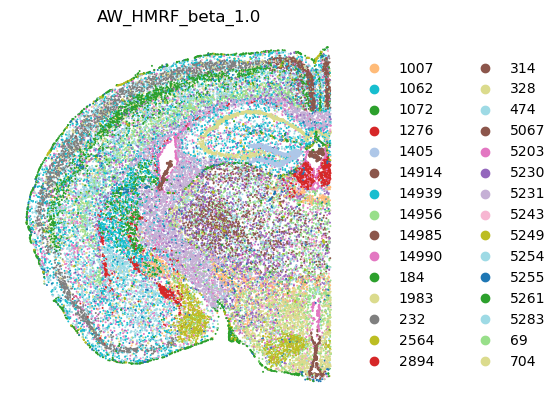

In [69]:
adata.obs['cluster_alias'] = (
    adata.obs['cluster_alias']
    .astype(float)
    .astype(int)
    .astype(str)
    .astype('category')
) 


adata.obs['AW_HMRF_beta_1.0_named'] = (
    adata.obs['AW_HMRF_beta_1.0_named']
    .astype(float)
    .astype(int)
    .astype(str)
    .astype('category')
)

align_visualization_colors(adata, 'AW_HMRF_beta_1.0_named', 'cluster_alias')
# 3. 绘图
sc.pl.spatial(
    adata, 
    color='AW_HMRF_beta_1.0_named',
    title='AW_HMRF_beta_1.0',
    spot_size=0.034,
    frameon=False
)